Data cleaning steps:

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("messy_customer_sales_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [ ]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


In [ ]:
df.isnull().sum()

,0
Customer_ID,1023
Name,0
Gender,1026
Age,951
City,1016
Signup_Date,0
Last_Purchase_Date,1012
Purchase_Amount,1021
Feedback_Score,1023
Email,0


In [ ]:
df[df.duplicated()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2032,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
3191,NaN,Travis Schneider,f,51.0,NaN,2025-04-20,2025-02-28,48750.0,5.0,bianca77@example.net,7623118785,India
4312,CUST8305,Stanley Cain,FEMALE,51.0,Bangalore,2023-08-14,2024-11-01,11432.0,6.0,calderonbrenda@example.org,4889366037,India
5611,CUST6288,Jonathon Kim,male,46.0,Chennai,2023-11-22,2025-03-21,3301.0,6.0,tparker@example.com,5266662560,India
5680,CUST2695,Lisa Durham,NaN,46.0,Chennai,2021-04-18,2024-10-10,6511.0,3.0,andrew34@example.com,2235480149,India
5899,CUST8841,Amanda Hill,NaN,34.0,chennai,2022-09-11,2025-03-13,42092.0,4.0,ryanriley@example.net,3466026146,India
6070,CUST10780,Emily Smith,NaN,23.0,Kolkata,2023-12-09,2024-10-28,18027.0,5.0,perezchristopher@example.com,3032282870,India
6240,CUST9745,David Morales,NaN,56.0,NaN,2023-02-18,2024-12-14,49107.0,7.0,juliaknapp@example.com,9436163110,India
6425,CUST4631,George Villa,m,26.0,Mumbai,2022-05-21,2025-06-17,NaN,8.0,davidmarquez@example.com,8869465862,India
6498,CUST1711,Stephanie Elliott,NaN,44.0,MUMBAI,2023-05-17,2025-07-12,11349.0,9.0,nfischer@example.com,3270872546,NaN


In [ ]:
for col in df.columns:
  if df[col].nunique() < 20:
    print(df[col].value_counts())
    print('-'*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
df.dropna(subset=['Customer_ID'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,934
Age,859
City,918
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,927
Feedback_Score,905
Email,0


In [ ]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [ ]:
import re
def extract_age(age):
    age_num = re.findall('[0-9]+',str(age))
    if len(age_num) > 0:
        return age_num[0]
    else:
        return age

df['Age'] = df['Age'].apply(lambda x: extract_age(x))

In [ ]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', nan, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', 'nan years', '39',
       '49', '47', '42', '44', '64', '53', '60', '45', '21', '34', '33',
       '250', '3', '10'], dtype=object)

In [ ]:
df_age = df[df['Age'] != 'nan years']['Age']

In [ ]:
age_median = int(df_age.dropna().astype('int64').median())

In [ ]:
age_median

43

In [ ]:
df.replace('nan years', age_median, inplace = True)

In [ ]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', nan, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', 43, '39', '49',
       '47', '42', '44', '64', '53', '60', '45', '21', '34', '33', '250',
       '3', '10'], dtype=object)

In [ ]:
df['Age'].fillna(age_median, inplace= True)

/tmp/ipykernel_3140/2282361100.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median, inplace= True)


In [ ]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', 43, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', '39', '49', '47',
       '42', '44', '64', '53', '60', '45', '21', '34', '33', '250', '3',
       '10'], dtype=object)

In [ ]:
df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace= True)

/tmp/ipykernel_3140/1670028703.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace= True)


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,934
Age,0
City,918
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,0
Feedback_Score,905
Email,0


In [ ]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', 43, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', '39', '49', '47',
       '42', '44', '64', '53', '60', '45', '21', '34', '33', '250', '3',
       '10'], dtype=object)

In [ ]:
df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace= True)

/tmp/ipykernel_3140/3587090209.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace= True)


In [ ]:
for col in ['Gender','City','Country']:
  df[col].fillna(df[col].mode()[0], inplace= True)

/tmp/ipykernel_3140/3409899074.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace= True)


In [ ]:
df['Last_Purchase_Date'].ffill(inplace= True)

/tmp/ipykernel_3140/3436263812.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last_Purchase_Date'].ffill(inplace= True)


Fixing Inconsistent Formatting


In [ ]:
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [ ]:
df['Gender']=df['Gender'].str.lower().str.strip()

In [ ]:
df['Gender'].replace({'m':'male','f':'female'}, inplace= True)

/tmp/ipykernel_3140/2973765601.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'m':'male','f':'female'}, inplace= True)


In [ ]:
df['Gender'].str.title().unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['City'].unique()

array([' KOLKATA ', ' Kolkata ', ' hyderabad ', ' CHENNAI ', ' kolkata ',
       ' BANGALORE ', ' Hyderabad ', ' HYDERABAD ', ' Mumbai ',
       ' chennai ', ' Delhi ', ' bangalore ', ' Bangalore ', ' delhi ',
       ' Chennai ', ' MUMBAI ', ' DELHI ', ' mumbai '], dtype=object)

In [ ]:
df['City']= df['City'].str.strip().str.title()

In [ ]:
df['City'].unique()

array(['Kolkata', 'Hyderabad', 'Chennai', 'Bangalore', 'Mumbai', 'Delhi'],
      dtype=object)

In [ ]:
df['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [ ]:
df['Country'] = df['Country'].str.title()

In [ ]:
df['Country'].replace({'Ind':'India'}, inplace= True)

/tmp/ipykernel_3140/14382768.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].replace({'Ind':'India'}, inplace= True)


In [ ]:
df['Country'].unique()

array(['India'], dtype=object)

In [ ]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,Kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,male,51,Kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,India
2,CUST3754,Brittney Martinez,female,62,Hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,female,40,Hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,India
4,CUST5683,Matthew Carroll,female,41,Chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India


In [ ]:
df.drop_duplicates(inplace= True)

In [ ]:
df[df.duplicated()].shape

(0, 12)

In [ ]:
df.drop_duplicates(subset=['Customer_ID'], keep= 'first', inplace= True)

Correcting Datatypes

In [ ]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [ ]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [ ]:
df['Age'] = df['Age'].astype('int64')

In [ ]:
df.dtypes

,0
Customer_ID,object
Name,object
Gender,object
Age,int64
City,object
Signup_Date,datetime64[ns]
Last_Purchase_Date,datetime64[ns]
Purchase_Amount,float64
Feedback_Score,float64
Email,object


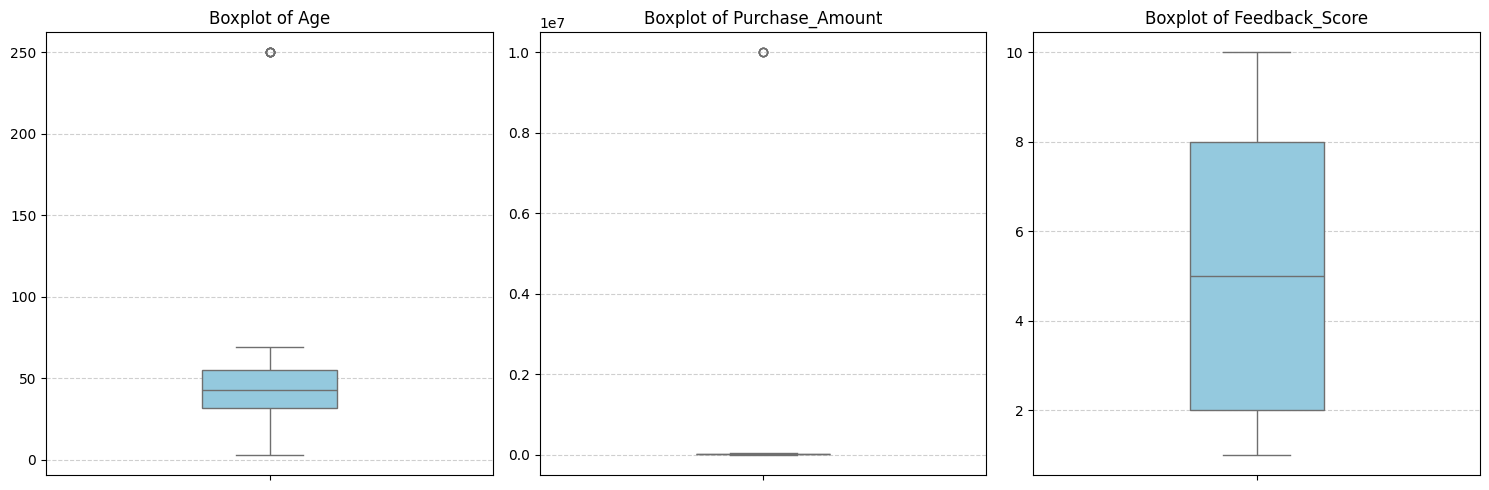

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age','Purchase_Amount', 'Feedback_Score']
plt.figure(figsize= (15, 5))

for i ,col in enumerate(cols, 1):
  plt.subplot(1,3,i)
  sns.boxplot(y=df[col], color='skyblue', width=0.3)
  plt.title(f'Boxplot of {col}', fontsize =12)
  plt.ylabel('')
  plt.grid(axis ='y' ,linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats


In [ ]:
stats.zscore(df[['Age','Purchase_Amount']])

array([[ 0.54925759, -0.01014723],
       [ 0.48399151,  0.07152616],
       [ 1.2019184 ,  0.0126395 ],
       ...,
       [-0.5602658 , -0.02332755],
       [-1.21292662,  0.07000736],
       [ 0.74505583, -0.0486725 ]])

Converting Negative value to positive using Numpy

In [ ]:
import numpy as np
z_scores = np.abs(stats.zscore(df[['Age','Purchase_Amount']]))

In [ ]:
df_clean = df[~(z_scores >3).any(axis = 1)]

In [ ]:
df_clean.shape

(8989, 12)

Checking , where outliers removed or not

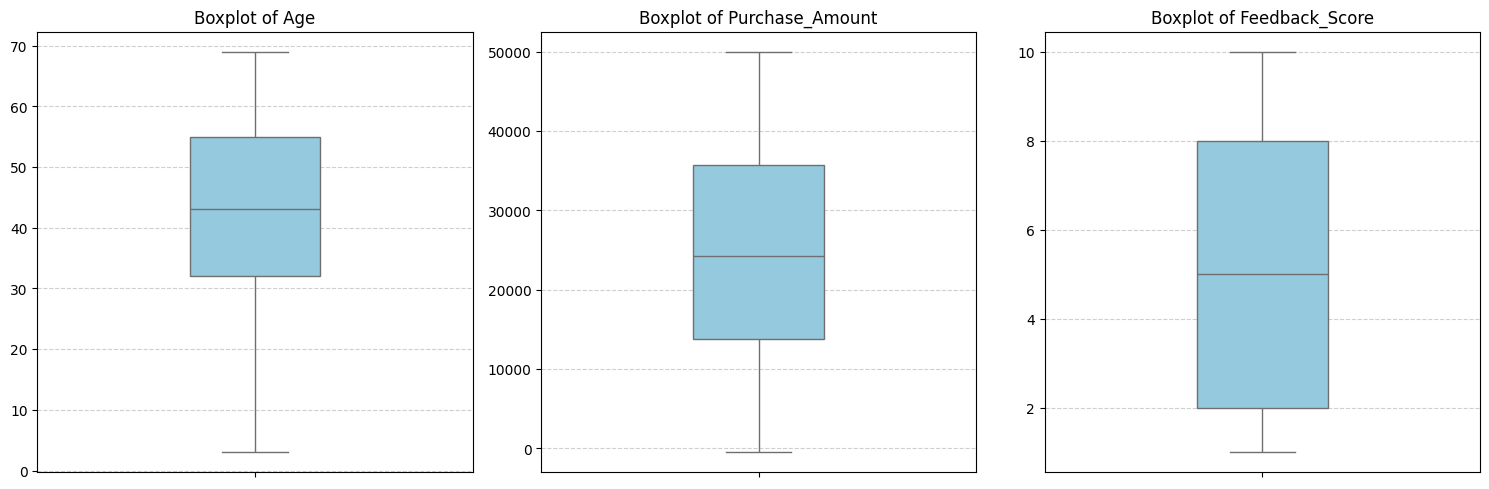

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age','Purchase_Amount', 'Feedback_Score']
plt.figure(figsize= (15, 5))

for i ,col in enumerate(cols, 1):
  plt.subplot(1,3,i)
  sns.boxplot(y=df_clean[col], color='skyblue', width=0.3)
  plt.title(f'Boxplot of {col}', fontsize =12)
  plt.ylabel('')
  plt.grid(axis ='y' ,linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

In [ ]:
# df.to_csv('/content/cleaned_data.csv', index=False)

In [ ]:
# df.to_csv(r'C:\Users\Admin\Desktop\cleaned_data.csv', index=False)

In [ ]:
# from google.colab import files
# files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>